## Task 1: Data Augmentation with ImageDataGenerator

Found 20 images belonging to 5 classes.


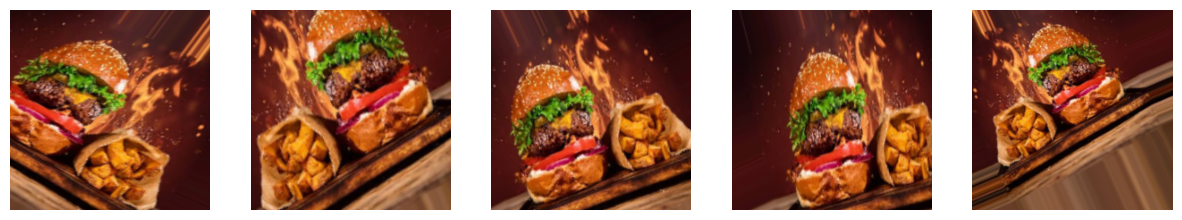

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

food_path = "Food-D/food_dataset"

datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15
)

food_data = datagen.flow_from_directory(
    food_path,
    target_size=(224, 224),
    batch_size=20,
    class_mode=None,
    shuffle=True
)

images = next(food_data)
image = images[0]

plt.figure(figsize=(15, 8))

for i in range(5):
    augmented = datagen.random_transform(image.copy())
    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented.astype("uint8"))
    plt.axis("off")

plt.show()

## Task 2: VGG16 Feature Extraction

Found 30 images belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Feature shape: (30, 25088)
Displaying: Food-D/sneaker_dataset\sneakers\sneakers1.jpg


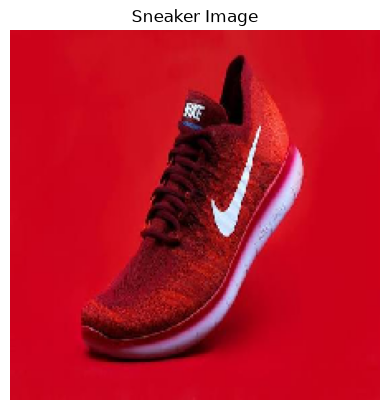

In [10]:
import tensorflow as tf
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

sneaker_path = "Food-D/sneaker_dataset"

vgg16 = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

sneaker_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

sneaker_data = sneaker_generator.flow_from_directory(
    sneaker_path,
    target_size=(224, 224),
    batch_size=30,
    class_mode=None,
    shuffle=False
)

sneaker_images = next(sneaker_data)

sneaker_features = vgg16.predict(sneaker_images)

sneaker_features = sneaker_features.reshape(
    sneaker_features.shape[0], -1
)

np.save("sneaker_features.npy", sneaker_features)

print("Feature shape:", sneaker_features.shape)

image_files = glob.glob(
    os.path.join(sneaker_path, "**", "*.jpg"),
    recursive=True
)

if len(image_files) == 0:
    image_files = glob.glob(
        os.path.join(sneaker_path, "**", "*.jpeg"),
        recursive=True
    )

if len(image_files) == 0:
    image_files = glob.glob(
        os.path.join(sneaker_path, "**", "*.png"),
        recursive=True
    )

if len(image_files) == 0:
    print("No image found in sneaker_dataset")
else:
    image_path = image_files[0]
    print("Displaying:", image_path)

    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    plt.imshow(img)
    plt.axis("off")
    plt.title("Sneaker Image")
    plt.show()

## Task 3: ResNet50 Fine-Tuning for Glasses Classification

Found 33 images belonging to 3 classes.
Found 8 images belonging to 3 classes.
Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.3333 - loss: 0.6294 - val_accuracy: 0.5000 - val_loss: -0.0624
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 816ms/step - accuracy: 0.3636 - loss: 0.0224 - val_accuracy: 0.5000 - val_loss: -0.3291
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 995ms/step - accuracy: 0.4242 - loss: -0.2942 - val_accuracy: 0.5000 - val_loss: -0.5910
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 817ms/step - accuracy: 0.3939 - loss: -0.3586 - val_accuracy: 0.5000 - val_loss: -0.6796
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 805ms/step - accuracy: 0.4545 - loss: -0.7022 - val_accuracy: 0.5000 - val_loss: -1.0581
Glasses images: 20
No glasses images: 20


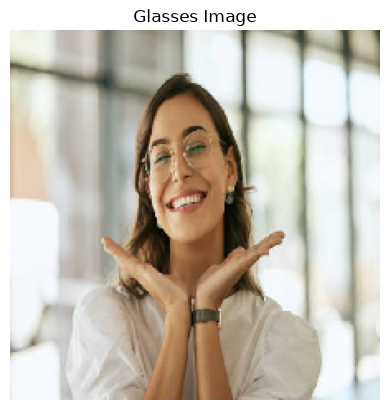

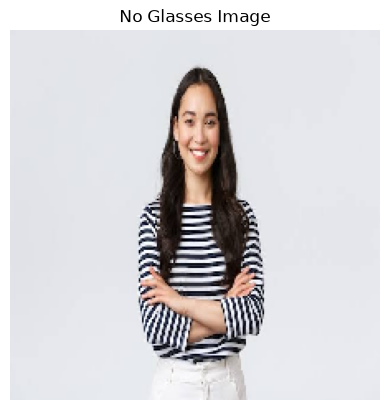

In [13]:
import tensorflow as tf
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.utils import load_img, img_to_array

glasses_path = "Food-D/glasses_dataset"

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=15
)

train_data = train_datagen.flow_from_directory(
    glasses_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode="binary",
    subset="training"
)

val_data = train_datagen.flow_from_directory(
    glasses_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode="binary",
    subset="validation"
)

resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in resnet.layers:
    layer.trainable = False

for layer in resnet.layers[-20:]:
    layer.trainable = True

model = models.Sequential([
    resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

glasses_files = []
no_glasses_files = []

for ext in ["*.jpg", "*.jpeg", "*.png"]:
    glasses_files.extend(
        glob.glob(os.path.join(glasses_path, "glasses", ext))
    )
    no_glasses_files.extend(
        glob.glob(os.path.join(glasses_path, "no_glasses", ext))
    )

print("Glasses images:", len(glasses_files))
print("No glasses images:", len(no_glasses_files))

if glasses_files:
    img = load_img(
        glasses_files[0],
        target_size=(224, 224)
    )

    plt.imshow(img)
    plt.axis("off")
    plt.title("Glasses Image")
    plt.show()

if no_glasses_files:
    img = load_img(
        no_glasses_files[0],
        target_size=(224, 224)
    )

    plt.imshow(img)
    plt.axis("off")
    plt.title("No Glasses Image")
    plt.show()

## Task 4: Feature Extraction vs Fine-Tuning

Found 36 images belonging to 4 classes.
Found 9 images belonging to 4 classes.
Classes: {'.ipynb_checkpoints': 0, 'plain': 1, 'printed': 2, 'striped': 3}
Number of classes: 4
Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 660ms/step - accuracy: 0.4722 - loss: 1.1925 - val_accuracy: 0.6667 - val_loss: 0.8087
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - accuracy: 0.8333 - loss: 0.4222 - val_accuracy: 1.0000 - val_loss: 0.3186
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - accuracy: 1.0000 - loss: 0.1829 - val_accuracy: 1.0000 - val_loss: 0.1349
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - accuracy: 0.9444 - loss: 0.1385 - val_accuracy: 1.0000 - val_loss: 0.1154
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - accuracy: 0.9722 - loss: 0.0621 - val_accuracy: 1.0000 - val_loss: 0.1100
Plain Tshirt images: 15
Printed Tshirt images: 15
Striped Tshirt images: 15


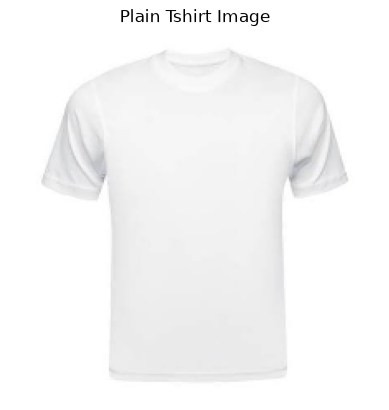

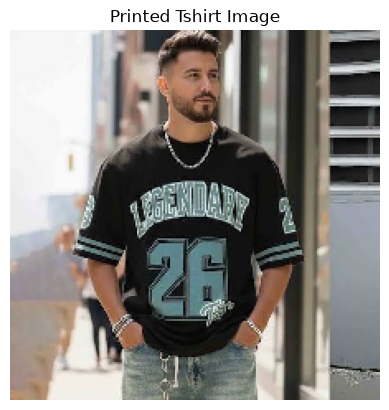

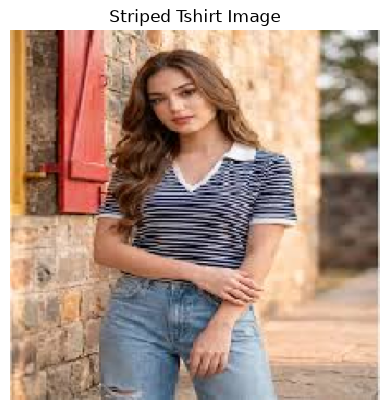

In [15]:
import tensorflow as tf
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.utils import load_img, img_to_array

tshirt_path = "Food-D/tshirt_dataset"

data_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    horizontal_flip=True
)

train_data = data_generator.flow_from_directory(
    tshirt_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode="categorical",
    subset="training"
)

val_data = data_generator.flow_from_directory(
    tshirt_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode="categorical",
    subset="validation"
)

print("Classes:", train_data.class_indices)
print("Number of classes:", train_data.num_classes)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

feature_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation="softmax")
])

feature_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

feature_history = feature_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)


plain_files = []
printed_files = []
striped_files = []

for ext in ["*.jpg", "*.jpeg", "*.png"]:
    plain_files.extend(
        glob.glob(os.path.join(tshirt_path, "plain", ext))
    )
    printed_files.extend(
        glob.glob(os.path.join(tshirt_path, "printed", ext))
    )
    striped_files.extend(
        glob.glob(os.path.join(tshirt_path, "striped", ext))
    )

print("Plain Tshirt images:", len(plain_files))
print("Printed Tshirt images:", len(printed_files))
print("Striped Tshirt images:", len(striped_files))

if plain_files:
    img = load_img(
        plain_files[0],
        target_size=(224, 224)
    )

    plt.imshow(img)
    plt.axis("off")
    plt.title("Plain Tshirt Image")
    plt.show()

if printed_files:
    img = load_img(
        printed_files[0],
        target_size=(224, 224)
    )

    plt.imshow(img)
    plt.axis("off")
    plt.title("Printed Tshirt Image")
    plt.show()

if striped_files:
    img = load_img(
        striped_files[0],
        target_size=(224, 224)
    )

    plt.imshow(img)
    plt.axis("off")
    plt.title("Striped Tshirt Image")
    plt.show()

In [16]:
fine_base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in fine_base_model.layers:
    layer.trainable = False

for layer in fine_base_model.layers[-20:]:
    layer.trainable = True

fine_model = models.Sequential([
    fine_base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation="softmax")
])

fine_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_history = fine_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 662ms/step - accuracy: 0.3889 - loss: 1.4606 - val_accuracy: 0.3333 - val_loss: 1.3574
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 319ms/step - accuracy: 0.3056 - loss: 1.4821 - val_accuracy: 0.3333 - val_loss: 1.3269
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 276ms/step - accuracy: 0.3333 - loss: 1.3788 - val_accuracy: 0.3333 - val_loss: 1.3326
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 290ms/step - accuracy: 0.4444 - loss: 1.2736 - val_accuracy: 0.4444 - val_loss: 1.1633
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step - accuracy: 0.5556 - loss: 1.0969 - val_accuracy: 0.4444 - val_loss: 1.1681


## Task 5: MobileNetV2 Transfer Learning for Headphones

Found 14 images belonging to 4 classes.
Found 3 images belonging to 4 classes.
Classes: {'.ipynb_checkpoints': 0, 'on_ear': 1, 'over_ear': 2, 'wireless': 3}
Number of classes: 4
Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.2857 - loss: 1.8857 - val_accuracy: 0.6667 - val_loss: 0.8944
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step - accuracy: 0.4286 - loss: 1.2067 - val_accuracy: 0.3333 - val_loss: 0.7888
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 967ms/step - accuracy: 0.7857 - loss: 0.5926 - val_accuracy: 0.3333 - val_loss: 0.7771
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9286 - loss: 0.2470 - val_accuracy: 0.6667 - val_loss: 0.6986
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 934ms/step - accuracy: 1.0000 - loss: 0.1543 - val_accuracy: 0.6667 - val_loss: 0.5782
.ipynb_checkpoints images: 0
on_ear images: 5


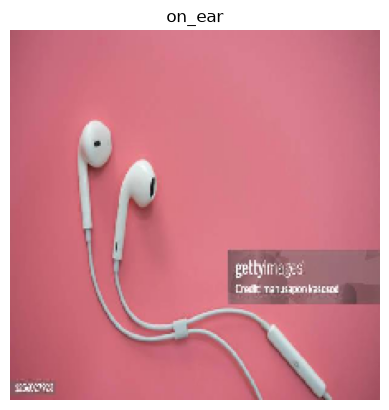

over_ear images: 6


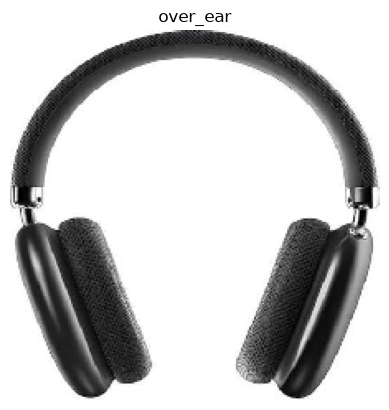

wireless images: 6


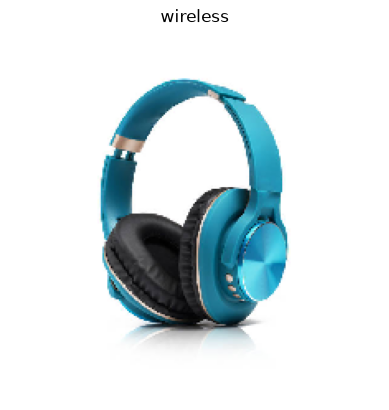

In [20]:
import tensorflow as tf
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.utils import load_img, img_to_array

headphone_path = "Food-D/headphones_dataset"

generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = generator.flow_from_directory(
    headphone_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical",
    subset="training"
)

val_data = generator.flow_from_directory(
    headphone_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode="categorical",
    subset="validation"
)

print("Classes:", train_data.class_indices)
print("Number of classes:", train_data.num_classes)

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

class_files = {}

for class_name in train_data.class_indices.keys():
    files = []
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        files.extend(
            glob.glob(
                os.path.join(headphone_path, class_name, ext)
            )
        )
    class_files[class_name] = files

for class_name, files in class_files.items():
    print(class_name, "images:", len(files))

    if files:
        img = load_img(
            files[0],
            target_size=(224, 224)
        )

        plt.imshow(img)
        plt.axis("off")
        plt.title(class_name)
        plt.show()

In [23]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

headphone_path = "Food-D/headphones_dataset"

headphone_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.15
)

train_headphones = headphone_generator.flow_from_directory(
    headphone_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode="categorical",
    subset="training"
)

val_headphones = headphone_generator.flow_from_directory(
    headphone_path,
    target_size=(224, 224),
    batch_size=8,
    class_mode="categorical",
    subset="validation"
)

print("Classes:", train_headphones.class_indices)
print("Number of classes:", train_headphones.num_classes)

mobile_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobile_model.trainable = False

headphone_model = models.Sequential([
    mobile_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(train_headphones.num_classes, activation="softmax")
])

headphone_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

headphone_history = headphone_model.fit(
    train_headphones,
    validation_data=val_headphones,
    epochs=5
)

Found 14 images belonging to 4 classes.
Found 3 images belonging to 4 classes.
Classes: {'.ipynb_checkpoints': 0, 'on_ear': 1, 'over_ear': 2, 'wireless': 3}
Number of classes: 4
Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.1429 - loss: 1.9811 - val_accuracy: 0.6667 - val_loss: 1.7008
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step - accuracy: 0.4286 - loss: 1.9329 - val_accuracy: 0.6667 - val_loss: 1.4728
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step - accuracy: 0.2857 - loss: 1.9033 - val_accuracy: 0.3333 - val_loss: 1.2403
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step - accuracy: 0.4286 - loss: 1.5793 - val_accuracy: 0.3333 - val_loss: 1.2855
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 628ms/step - accuracy: 0.3571 - loss: 1.4501 - val_accuracy: 0.3333 - val_loss: 1.0717
